In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import csv
from PIL import Image
import colorsys
import plotly.express as px
import cv2 as cv
import ast
import matplotlib.animation as animation

### Functions

Calculate average color

In [49]:
#function to convert rgb to hex
def rgb2hex(r,g,b):
    return "#{:02x}{:02x}{:02x}".format(r,g,b)

def calculate_average_color(image_path):
    """Calculate the average color of the image."""
    img = cv.imread(image_path)
    if img is None:
        return '#000000'  # If the image can't be read, return black.
    
    # Mask where the background (black) is excluded
    mask = np.all(img != [0, 0, 0], axis=-1)
    
    # Apply the mask to the image
    masked_img = img[mask]
    
    if masked_img.size == 0:
        return '#000000'  # If there are no valid pixels, return black.
    
    result = np.mean(masked_img, axis=0)
    hex_avg = rgb2hex(int(result[2]), int(result[1]), int(result[0]))
    return hex_avg

In [50]:
def average_color(pname, start_year=1998, end_year=2024):
    output_csv = f"output/0_output_csv/{pname}_average_color.csv"
    
    with open(output_csv, mode='w', newline='') as file:
        writer = csv.writer(file)
        writer.writerow(['Year', 'Month', 'Average_Hex'])
        
        for year in range(start_year, end_year + 1):
            for month in range(1, 13):
                folder_path = f"output/{pname}/{year}/{month:02d}"
                
                if not os.path.exists(folder_path):
                    continue
                
                for img_file in os.listdir(folder_path):
                    if img_file.endswith(".png"):
                        img_path = os.path.join(folder_path, img_file)
                        avg_color = calculate_average_color(img_path)
                        writer.writerow([year, month, avg_color])

Calculate greenness

What we see above is that it's quite difficult to discern average colour changes. What I want to try now is to score greenness of satelitte imagery. This is all pretty well outlined in [this stack overflow post.](https://stackoverflow.com/questions/56569418/estimating-the-percentage-of-green-in-an-image) This is enourmously helpful, because the Hue-Saturation-Value (HSV) color space identifies green pixels directly and targets the green component regardless of the intensity or brightness.

In [51]:
def calculate_greenness(image_path):
    # Open image and convert to HSV
    img = Image.open(image_path).convert("HSV")
    
    #convert to numpy array because its faster
    img_array = np.array(img)
    
    #extract hue channel
    hue = img_array[:, :, 0]
    
    #make mask of zeros in which we will set greens to 1
    mask = np.zeros_like(hue, dtype=np.uint8)
    #between 80 and 90 is green in the HSV color space
    mask[(hue > 80) & (hue < 90)] = 1
    
    #compute the percentage of green pixels
    percentage_green = (np.sum(mask) / mask.size) * 100
    
    return percentage_green

In [52]:
def average_greenness_csv(pname, start_year=1998, end_year=2024):
    output_csv = f"output/0_output_csv/{pname}_average_greenness.csv"
    
    with open(output_csv, mode='w', newline='') as file:
        writer = csv.writer(file)
        writer.writerow(['Year', 'Month', 'Greenness_Percentage'])
        
        for year in range(start_year, end_year + 1):
            for month in range(1, 13):
                folder_path = f"output/{pname}/{year}/{month:02d}"
                
                if not os.path.exists(folder_path):
                    continue
                
                for img_file in os.listdir(folder_path):
                    if img_file.endswith(".png"):
                        img_path = os.path.join(folder_path, img_file)
                        avg_color = calculate_greenness(img_path)
                        writer.writerow([year, month, avg_color])


Making simple heatmap

In [53]:
def colour_heatmap(region_name):
    # Read the CSV file
    csv_file = f'output/0_output_csv/{region_name}_average_color.csv'
    print(csv_file)
    dataframe = pd.read_csv(csv_file)

    # Reformatting the data for a clearer representation in a heatmap
    pivot_df = dataframe.pivot(index='Year', columns='Month', values='Average_Hex')
    pivot_df = pivot_df.fillna('#FFFFFF')
    # Create a grid of colors based on the hex values
    color_grid = [[pivot_df.iloc[y, x] for x in range(pivot_df.shape[1])] for y in range(pivot_df.shape[0])]

    # Plot the heatmap
    plt.figure(figsize=(10, 2))
    for y in range(pivot_df.shape[0]):
        for x in range(pivot_df.shape[1]):
            plt.gca().add_patch(plt.Rectangle((x, y), 1, 1, color=color_grid[y][x]))

    # Set ticks and labels
    plt.xticks(range(len(pivot_df.columns)), pivot_df.columns)
    plt.yticks(range(len(pivot_df.index)), pivot_df.index)
    plt.xlim(0, len(pivot_df.columns))
    plt.ylim(0, len(pivot_df.index))
    plt.gca().invert_yaxis()

    # Adding the hex color codes on top of the heatmap
    for y in range(pivot_df.shape[0]):
        for x in range(pivot_df.shape[1]):
            plt.text(x + 0.5, y + 0.5, pivot_df.iloc[y, x], ha='center', va='center', color='white', fontsize=8)

    plt.title('Heatmap of Average Hex Colors by Month and Year')
    plt.xlabel('Month')
    plt.ylabel('Year')

    plt.show()

In [54]:
def green_heatmap(region_name):
    # Read the CSV file
    csv_file = f'output/0_output_csv/{region_name}_average_greenness.csv'
    df = pd.read_csv(csv_file)

    # Pivot the dataframe
    pivot_df = df.pivot(index='Year', columns='Month', values='Greenness_Percentage')
    pivot_df = pivot_df.fillna(0)

    # Create the heatmap
    plt.figure(figsize=(10, 2))
    sns.heatmap(pivot_df, cmap='Greens', annot=True, fmt=".1f")
    plt.title(f'Greenness by Month and Year - {region_name}')
    plt.xlabel('Month')
    plt.ylabel('Year')
    plt.show()

### Try it out yourself

1. Average colour

output/0_output_csv/circles_average_color.csv


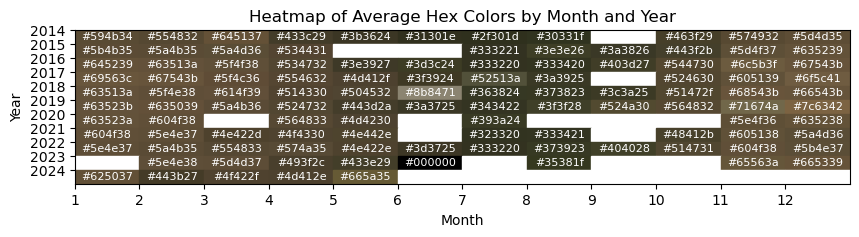

In [55]:
region = "circles"

#calculate average color
average_color(region)
#generate heatmap
colour_heatmap(region)

2. Calculate Greenness

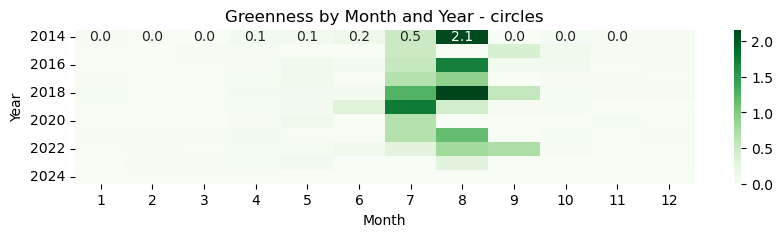

In [56]:
#calculate average color
average_greenness_csv(region)
#generate heatmap
green_heatmap(region)

Redo calculations

In [57]:
def calculate_greenness(img_path):
    img = cv.imread(img_path, cv.IMREAD_UNCHANGED)
    if img is None:
        return 0  # If the image can't be read, consider it as zero greenness.
    
    # Separate the color channels and the alpha channel
    bgr = img[:, :, :3]
    alpha = img[:, :, 3] if img.shape[2] == 4 else np.ones_like(img[:, :, 0]) * 255
    
    # Convert the BGR image to HSV color space
    img_hsv = cv.cvtColor(bgr, cv.COLOR_BGR2HSV)

    # Define the HSV range for light to dark green
    hsv_color1 = np.asarray([30, 40, 40])   # Lower bound of green
    hsv_color2 = np.asarray([90, 255, 255]) # Upper bound of green

    # Create a mask with the specified green range
    green_mask = cv.inRange(img_hsv, hsv_color1, hsv_color2)
    
    # Mask out the transparent areas by combining the green mask and the alpha channel
    final_mask = cv.bitwise_and(green_mask, green_mask, mask=alpha)
    
    # Calculate the area of the masked region (green area)
    green_area = cv.countNonZero(final_mask)
    
    # Calculate the total land area (non-transparent area)
    total_land_area = cv.countNonZero(alpha)
    
    # Check for division by zero
    if total_land_area == 0:
        return 0  # No non-transparent area, consider it as zero greenness.
    
    # Calculate the percentage of the green area
    green_area_percentage = (green_area / total_land_area) * 100
    
    return green_area_percentage

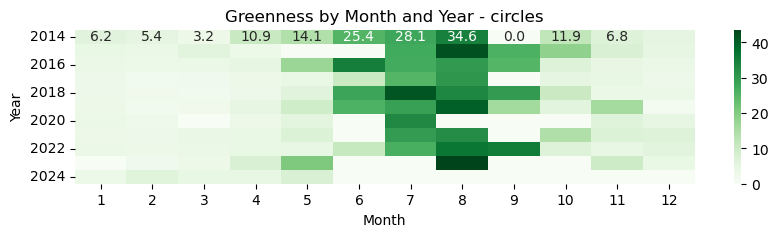

In [58]:
region = "circles"

average_greenness_csv(region)
#generate heatmap
green_heatmap(region)

And this time calculate which shade of greenness we are falling into

In [59]:
def average_green_shade(image_path):
    image = Image.open(image_path)
    image = image.convert('RGB')  # Ensure image is in RGB format
    pixels = np.array(image)
    
    # Convert RGB image to HSV
    hsv_image = cv.cvtColor(pixels, cv.COLOR_RGB2HSV)
    
    # Define the HSV range for light to dark green
    """
    hsv_color1 = np.asarray([35, 50, 50])   # Lower bound of green
    hsv_color2 = np.asarray([85, 255, 255]) # Upper bound of green
    """
    hsv_color1 = np.asarray([30, 40, 40])   # Lower bound of green
    hsv_color2 = np.asarray([90, 255, 255]) # Upper bound of green
    
    # Create a mask for green pixels
    mask = cv.inRange(hsv_image, hsv_color1, hsv_color2)
    
    # Apply mask to the original image to extract green pixels
    green_pixels = pixels[mask > 0]
    
    if green_pixels.size == 0:
        return (0, 0, 0)  # Return black if there are no green pixels

    # Calculate the average RGB values of the green pixels
    average_green = np.mean(green_pixels, axis=0)
    return tuple(average_green.astype(int))

In [60]:
def average_green_shade_csv(pname, start_year=1998, end_year=2024):
    output_csv = f"output/0_output_csv/{pname}_average_green_shade.csv"
    
    with open(output_csv, mode='w', newline='') as file:
        writer = csv.writer(file)
        writer.writerow(['Year', 'Month', 'Green Shade'])
        
        for year in range(start_year, end_year + 1):
            for month in range(1, 13):
                folder_path = f"output/{pname}/{year}/{month:02d}"
                
                if not os.path.exists(folder_path):
                    continue
                
                for img_file in os.listdir(folder_path):
                    if img_file.endswith(".png"):
                        img_path = os.path.join(folder_path, img_file)
                        avg_color = average_green_shade(img_path)
                        writer.writerow([year, month, avg_color])


In [61]:
region = "City of Cape Town Metropolitan Municipality"

average_green_shade_csv(region)

In [62]:
#visualize the data
csv_file = f'output/0_output_csv/{region}_average_green_shade.csv'
df = pd.read_csv(csv_file)
#create a new column for the hex values
def to_tuple_and_hex(rgb_str):
    #turn the string into a tuple
    rgb = ast.literal_eval(rgb_str)
    return '#{:02x}{:02x}{:02x}'.format(int(rgb[0]), int(rgb[1]), int(rgb[2]))

# Apply the function to the 'Green Shade' column
df['Average_Hex'] = df['Green Shade'].apply(to_tuple_and_hex)
df.drop('Green Shade', axis=1, inplace=True)

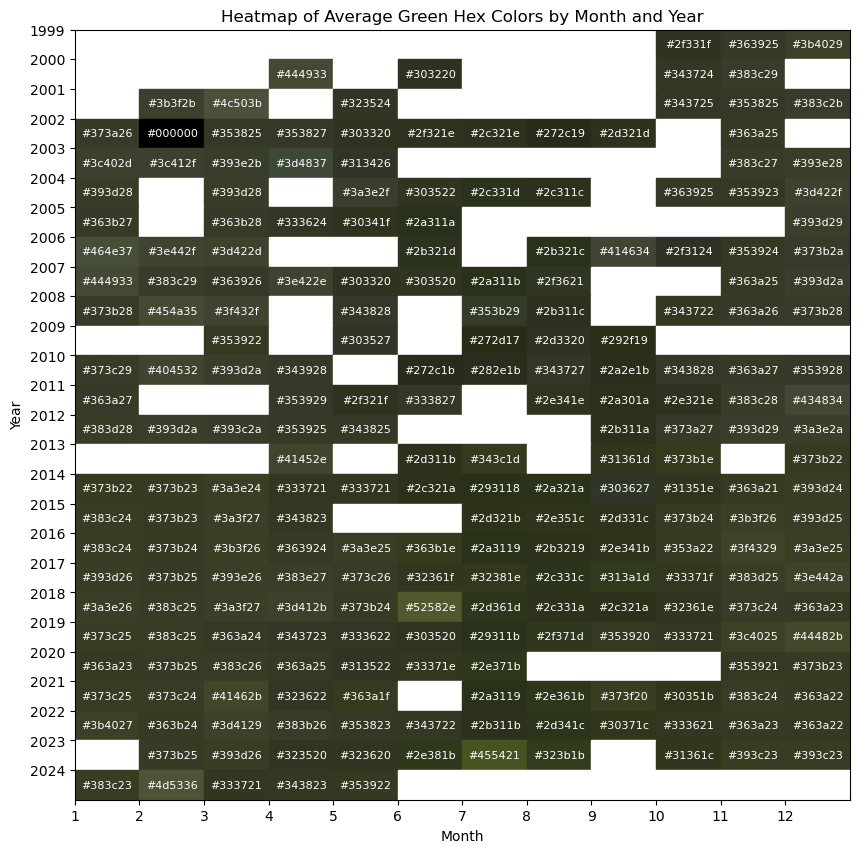

In [63]:
# Reformatting the data for a clearer representation in a heatmap
pivot_df = df.pivot(index='Year', columns='Month', values='Average_Hex')
pivot_df = pivot_df.fillna('#FFFFFF')
# Create a grid of colors based on the hex values
color_grid = [[pivot_df.iloc[y, x] for x in range(pivot_df.shape[1])] for y in range(pivot_df.shape[0])]

# Plot the heatmap
plt.figure(figsize=(10, 10))
for y in range(pivot_df.shape[0]):
    for x in range(pivot_df.shape[1]):
        plt.gca().add_patch(plt.Rectangle((x, y), 1, 1, color=color_grid[y][x]))

# Set ticks and labels
plt.xticks(range(len(pivot_df.columns)), pivot_df.columns)
plt.yticks(range(len(pivot_df.index)), pivot_df.index)
plt.xlim(0, len(pivot_df.columns))
plt.ylim(0, len(pivot_df.index))
plt.gca().invert_yaxis()

# Adding the hex color codes on top of the heatmap
for y in range(pivot_df.shape[0]):
    for x in range(pivot_df.shape[1]):
        plt.text(x + 0.5, y + 0.5, pivot_df.iloc[y, x], ha='center', va='center', color='white', fontsize=8)

plt.title('Heatmap of Average Green Hex Colors by Month and Year')
plt.xlabel('Month')
plt.ylabel('Year')

plt.show()


Well this is not turing out the way I expected...

In [64]:
def record_green_shades(image_path):
    image = Image.open(image_path)
    image = image.convert('RGB')  # Ensure image is in RGB format
    pixels = np.array(image)
    
    # Convert RGB image to HSV
    hsv_image = cv.cvtColor(pixels, cv.COLOR_RGB2HSV)
    
    # Define the HSV range for light to dark green
    """
    Bigger bounds for green
    hsv_color1 = np.asarray([30, 40, 40])   # Lower bound of green
    hsv_color2 = np.asarray([90, 255, 255]) # Upper bound of green
    """
    hsv_color1 = np.asarray([35, 50, 50])   # Lower bound of green
    hsv_color2 = np.asarray([85, 255, 255]) # Upper bound of green

    # Create a mask for green pixels
    mask = cv.inRange(hsv_image, hsv_color1, hsv_color2)
    
    # Apply mask to the original image to extract green pixels
    green_pixels = pixels[mask > 0]
    
    if green_pixels.size == 0:
        return []  # Return an empty list if there are no green pixels

    # Convert green pixels to a list of RGB tuples
    green_pixel_list = [tuple(pixel) for pixel in green_pixels]
    
    return green_pixel_list

In [65]:
def plot_green_shades(green_pixel_list, label, color, alpha=0.5):
    if not green_pixel_list:
        print(f"No green pixels found for {label}.")
        return

    # Convert the list of tuples into a numpy array for easier manipulation
    green_pixel_array = np.array(green_pixel_list)
    
    # Extract the green channel values
    green_channel_values = green_pixel_array[:, 1]
    
    # Plot the histogram of green channel values
    plt.hist(green_channel_values, bins=20, color=color, alpha=alpha, label=label, edgecolor='black')


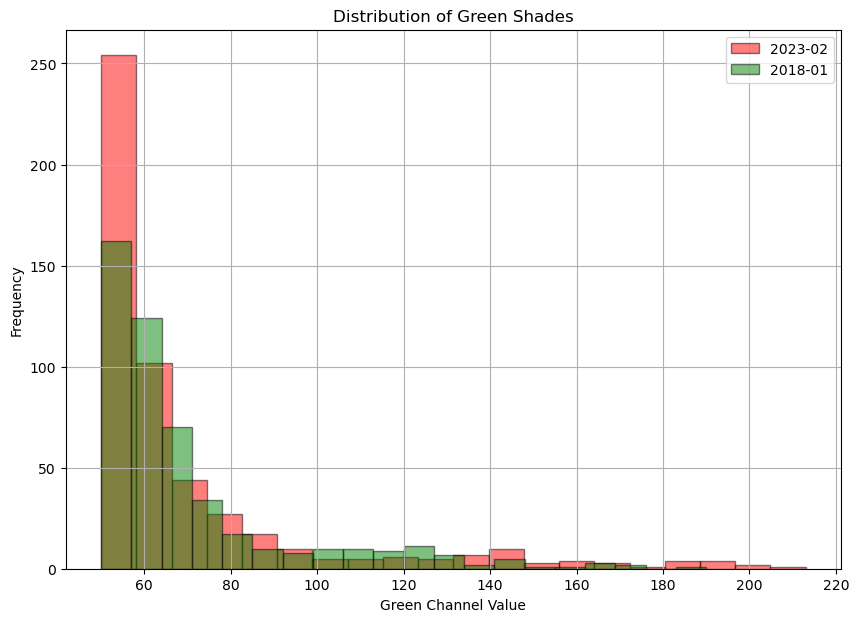

In [66]:
region = "City of Cape Town Metropolitan Municipality"

year_x1 = "2018"
month_x1 = "01"
image_path_x1 = f'output/{region}/{year_x1}/{month_x1}/{region}_{year_x1}-{month_x1}-01.png'
green_shades_x1 = record_green_shades(image_path_x1)

year_x2 = "2023"
month_x2 = "02"
image_path_x2 = f'output/{region}/{year_x2}/{month_x2}/{region}_{year_x2}-{month_x2}-01.png'
green_shades_x2 = record_green_shades(image_path_x2)

plt.figure(figsize=(10, 7))

plot_green_shades(green_shades_x2, label=f'{year_x2}-{month_x2}', color='red', alpha=0.5)
plot_green_shades(green_shades_x1, label=f'{year_x1}-{month_x1}', color='green', alpha=0.5)

plt.title('Distribution of Green Shades')
plt.xlabel('Green Channel Value')
plt.ylabel('Frequency')
plt.legend()
plt.grid(True)
plt.show()

## Detecting Browness

3. Detecting the amount of browness/specifying a range

In [67]:
def calculate_brownness(image_path):
    # Open image and convert to HSV
    img = Image.open(image_path).convert("HSV")
    
    #convert to numpy array because its faster
    img_array = np.array(img)
    
    #extract hue channel
    hue = img_array[:, :, 0]
    
    #make mask of zeros in which we will set greens to 1
    mask = np.zeros_like(hue, dtype=np.uint8)
    #between 80 and 90 is green in the HSV color space
    mask[(hue > 80) & (hue < 90)] = 1
    
    #compute the percentage of green pixels
    percentage_green = (np.sum(mask) / mask.size) * 100
    
    return percentage_green

Mask area between cetain colour codes

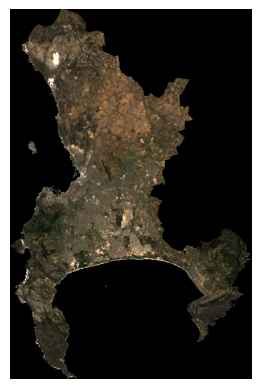

In [10]:
import cv2 as cv
import matplotlib.pyplot as plt

# Define the image path
img_path = "output/City of Cape Town Metropolitan Municipality/2002/01/City of Cape Town Metropolitan Municipality_2002-01-01.png"

# Read the image with OpenCV
img = cv.imread(img_path, cv.IMREAD_UNCHANGED)

# Convert the image from BGR to RGB
img_rgb = cv.cvtColor(img, cv.COLOR_BGR2RGB)

# Display the image using Matplotlib
plt.imshow(img_rgb)
plt.axis('off')
plt.show()

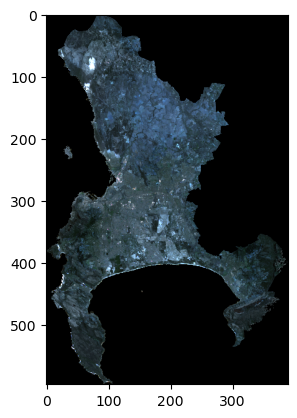

In [6]:
img_path = "output/City of Cape Town Metropolitan Municipality/2002/01/City of Cape Town Metropolitan Municipality_2002-01-01.png"
img = cv.imread(img_path)

plt.imshow(img)
plt.show()

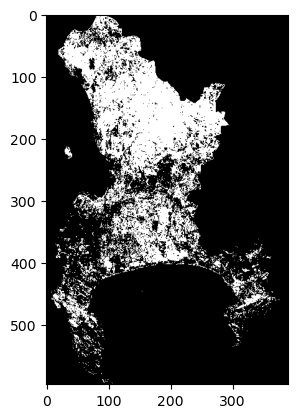

In [74]:
img_path = "output/City of Cape Town Metropolitan Municipality/2002/01/City of Cape Town Metropolitan Municipality_2002-01-01.png"
img = cv.imread(img_path)   # you can read in images with opencv
img_hsv = cv.cvtColor(img, cv.COLOR_BGR2HSV)

hsv_color1 = np.asarray([10, 50, 50])   # white!
hsv_color2 = np.asarray([20, 255, 255])   # yellow! note the order

mask = cv.inRange(img_hsv, hsv_color1, hsv_color2)

plt.imshow(mask, cmap='gray')   # this colormap will display in black / white
plt.show()

Calculate mask area

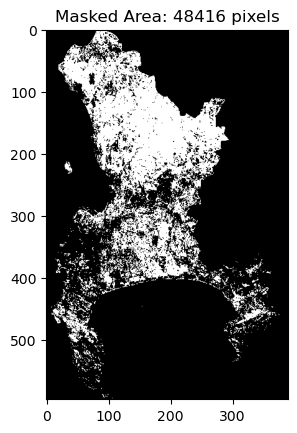

In [75]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

# Define the image path
img_path = "output/City of Cape Town Metropolitan Municipality/2002/01/City of Cape Town Metropolitan Municipality_2002-01-01.png"

# Read the image with OpenCV
img = cv.imread(img_path)

# Separate the color channels and the alpha channel
bgr = img[:, :, :3]
alpha = img[:, :, 3] if img.shape[2] == 4 else np.ones_like(img[:, :, 0]) * 255

# Convert the BGR image to HSV color space
img_hsv = cv.cvtColor(bgr, cv.COLOR_BGR2HSV)

# Define the HSV range for light to dark brown
hsv_color1 = np.asarray([10, 50, 50])   # Lower bound of brown
hsv_color2 = np.asarray([20, 255, 255]) # Upper bound of brown

# Create a mask with the specified brown range
mask = cv.inRange(img_hsv, hsv_color1, hsv_color2)

# Mask out the transparent areas by combining the brown mask and the alpha channel
final_mask = cv.bitwise_and(mask, mask, mask=alpha)

# Calculate the area of the masked region
# The area in pixels is the number of white pixels in the final mask
area = cv.countNonZero(final_mask)

# Display the final mask
plt.imshow(final_mask, cmap='gray')
plt.title(f'Masked Area: {area} pixels')
plt.show()

Below I flip the image to being transparent and black, from the previous build up

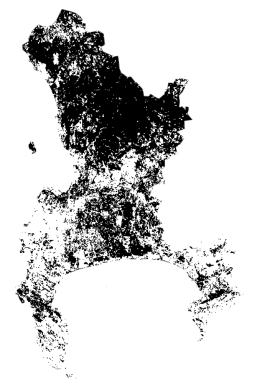

In [12]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

# Define the image path
img_path = "output/City of Cape Town Metropolitan Municipality/2002/01/City of Cape Town Metropolitan Municipality_2002-01-01.png"

# Read the image with OpenCV
img = cv.imread(img_path, cv.IMREAD_UNCHANGED)

# Separate the color channels and the alpha channel
bgr = img[:, :, :3]
alpha = img[:, :, 3] if img.shape[2] == 4 else np.ones_like(img[:, :, 0]) * 255

# Convert the BGR image to HSV color space
img_hsv = cv.cvtColor(bgr, cv.COLOR_BGR2HSV)

# Define the HSV range for light to dark brown
hsv_color1 = np.asarray([10, 50, 50])   # Lower bound of brown
hsv_color2 = np.asarray([20, 255, 255]) # Upper bound of brown

# Create a mask with the specified brown range
mask = cv.inRange(img_hsv, hsv_color1, hsv_color2)

# Mask out the transparent areas by combining the brown mask and the alpha channel
final_mask = cv.bitwise_and(mask, mask, mask=alpha)

# Create a new image with the same dimensions and 4 channels (RGBA)
result = np.zeros_like(img)

# Set the alpha channel of the new image
result[:, :, 3] = alpha

# Set the brown areas to black and non-brown areas to transparent
result[:, :, :3][final_mask > 0] = 0       # Brown areas to black
result[:, :, 3][final_mask == 0] = 0       # Non-brown areas to transparent

# Display the final mask
plt.imshow(result)  # Display the RGBA image directly with matplotlib
plt.axis('off')

plt.savefig('output/brown_mask.svg')
plt.show()


Then define the color range according to reference as 21-40 degrees in the hsl color space [[Source here]](https://www.rapidtables.com/web/color/RGB_Color.html)

Image dimensions: (596, 389, 4)
Mask created with 24415 pixels in range


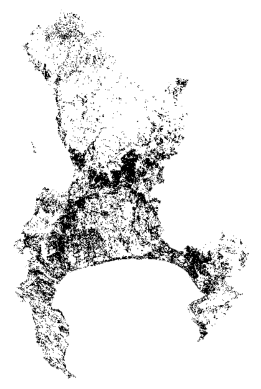

In [11]:
# Define the image path
img_path = "output/City of Cape Town Metropolitan Municipality/2002/01/City of Cape Town Metropolitan Municipality_2002-01-01.png"

# Read the image with OpenCV
img = cv.imread(img_path, cv.IMREAD_UNCHANGED)
if img is None:
    print("Error: Image not found or unable to read")
else:
    print(f"Image dimensions: {img.shape}")

# Separate the color channels and the alpha channel
bgr = img[:, :, :3]
alpha = img[:, :, 3] if img.shape[2] == 4 else np.ones_like(img[:, :, 0]) * 255

# Convert the BGR image to HSV color space
img_hsv = cv.cvtColor(bgr, cv.COLOR_BGR2HSV)

# Define the HSV range for brown colors more broadly
hue_start, hue_end = 21, 40
saturation_start, saturation_end = 50, 255
value_start, value_end = 50, 255

# Create a mask with the specified hue, saturation, and value ranges
lower_bound = np.array([hue_start, saturation_start, value_start])
upper_bound = np.array([hue_end, saturation_end, value_end])
mask = cv.inRange(img_hsv, lower_bound, upper_bound)

# Check if the mask has been created correctly
print(f"Mask created with {np.sum(mask > 0)} pixels in range")

# Mask out the transparent areas by combining the brown mask and the alpha channel
final_mask = cv.bitwise_and(mask, mask, mask=alpha)

# Create a new image with the same dimensions and 4 channels (RGBA)
result = np.zeros_like(img)

# Set the alpha channel of the new image
result[:, :, 3] = alpha

# Set the brown areas to black and non-brown areas to transparent
result[:, :, :3][final_mask > 0] = 0       # Brown areas to black
result[:, :, 3][final_mask == 0] = 0       # Non-brown areas to transparent

# Display the final mask
plt.imshow(cv.cvtColor(result, cv.COLOR_BGRA2RGBA))  # Display the RGBA image directly with matplotlib
plt.axis('off')

plt.savefig('output/brown_mask.svg')
plt.show()


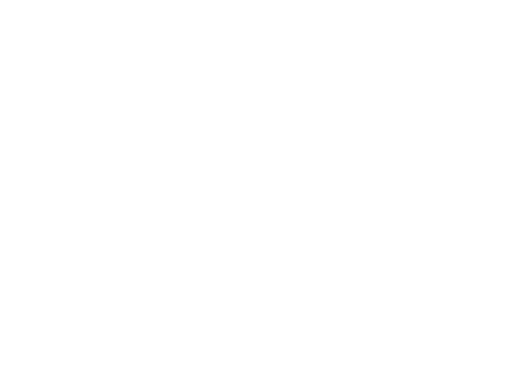

ValueError: The truth value of an array with more than one element is ambiguous. Use a.any() or a.all()

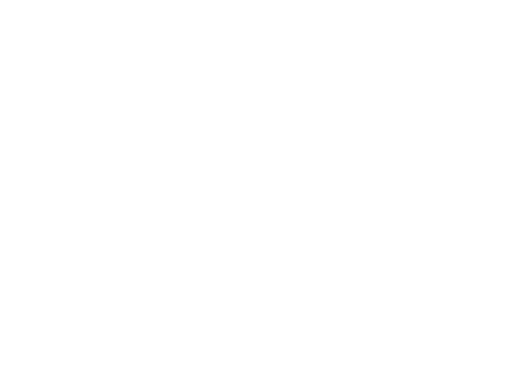

In [82]:
# Define the image path
img_path = "output/City of Cape Town Metropolitan Municipality/2002/01/City of Cape Town Metropolitan Municipality_2002-01-01.png"

# Read the image with OpenCV
img = cv.imread(img_path, cv.IMREAD_UNCHANGED)

plt.axis('off')
plt.show(img)

In [71]:
'''import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

# Define the image path
img_path = "output/City of Cape Town Metropolitan Municipality/2014/02/City of Cape Town Metropolitan Municipality_2014-02-01.png"

# Read the image with OpenCV
img = cv.imread(img_path, cv.IMREAD_UNCHANGED)

# Separate the color channels and the alpha channel
bgr = img[:, :, :3]
alpha = img[:, :, 3] if img.shape[2] == 4 else np.ones_like(img[:, :, 0]) * 255

# Convert the BGR image to HSV color space
img_hsv = cv.cvtColor(bgr, cv.COLOR_BGR2HSV)

# Define the HSV range for light to dark brown
hsv_color1 = np.asarray([10, 50, 50])   # Lower bound of brown
hsv_color2 = np.asarray([20, 255, 255]) # Upper bound of brown

# Create a mask with the specified brown range
brown_mask = cv.inRange(img_hsv, hsv_color1, hsv_color2)

# Mask out the transparent areas by combining the brown mask and the alpha channel
final_mask = cv.bitwise_and(brown_mask, brown_mask, mask=alpha)

# Calculate the area of the masked region (brown area)
brown_area = cv.countNonZero(final_mask)

# Calculate the total land area (non-transparent area)
total_land_area = cv.countNonZero(alpha)

# Calculate the percentage of the brown area
brown_area_percentage = (brown_area / total_land_area) * 100

# Display the final mask
plt.imshow(final_mask, cmap='gray')
plt.title(f'Brown Area: {brown_area} pixels ({brown_area_percentage:.2f}%)')
plt.show()

print(f'Total Land Area: {total_land_area} pixels')
print(f'Brown Area: {brown_area} pixels')
print(f'Brown Area Percentage: {brown_area_percentage:.2f}%')'''

'import cv2 as cv\nimport numpy as np\nimport matplotlib.pyplot as plt\n\n# Define the image path\nimg_path = "output/City of Cape Town Metropolitan Municipality/2014/02/City of Cape Town Metropolitan Municipality_2014-02-01.png"\n\n# Read the image with OpenCV\nimg = cv.imread(img_path, cv.IMREAD_UNCHANGED)\n\n# Separate the color channels and the alpha channel\nbgr = img[:, :, :3]\nalpha = img[:, :, 3] if img.shape[2] == 4 else np.ones_like(img[:, :, 0]) * 255\n\n# Convert the BGR image to HSV color space\nimg_hsv = cv.cvtColor(bgr, cv.COLOR_BGR2HSV)\n\n# Define the HSV range for light to dark brown\nhsv_color1 = np.asarray([10, 50, 50])   # Lower bound of brown\nhsv_color2 = np.asarray([20, 255, 255]) # Upper bound of brown\n\n# Create a mask with the specified brown range\nbrown_mask = cv.inRange(img_hsv, hsv_color1, hsv_color2)\n\n# Mask out the transparent areas by combining the brown mask and the alpha channel\nfinal_mask = cv.bitwise_and(brown_mask, brown_mask, mask=alpha)\n\n#

In [72]:
def calculate_brownness(img_path):
    img = cv.imread(img_path, cv.IMREAD_UNCHANGED)
    if img is None:
        return 0  # If the image can't be read, consider it as zero brownness.
    
    # Separate the color channels and the alpha channel
    bgr = img[:, :, :3]
    alpha = img[:, :, 3] if img.shape[2] == 4 else np.ones_like(img[:, :, 0]) * 255
    
    # Convert the BGR image to HSV color space
    img_hsv = cv.cvtColor(bgr, cv.COLOR_BGR2HSV)

    # Define the HSV range for light to dark brown
    hsv_color1 = np.asarray([10, 50, 50])   # Lower bound of brown
    hsv_color2 = np.asarray([20, 255, 255]) # Upper bound of brown

    # Create a mask with the specified brown range
    brown_mask = cv.inRange(img_hsv, hsv_color1, hsv_color2)
    
    # Mask out the transparent areas by combining the brown mask and the alpha channel
    final_mask = cv.bitwise_and(brown_mask, brown_mask, mask=alpha)
    
    # Calculate the area of the masked region (brown area)
    brown_area = cv.countNonZero(final_mask)
    
    # Calculate the total land area (non-transparent area)
    total_land_area = cv.countNonZero(alpha)
    
    # Check for division by zero
    if total_land_area == 0:
        return 0  # No non-transparent area, consider it as zero brownness.
    
    # Calculate the percentage of the brown area
    brown_area_percentage = (brown_area / total_land_area) * 100
    
    return brown_area_percentage

In [73]:
def average_brownness_csv(pname, start_year=1998, end_year=2024):
    output_csv = f"output/0_output_csv/{pname}_average_brownness.csv"
    
    with open(output_csv, mode='w', newline='') as file:
        writer = csv.writer(file)
        writer.writerow(['Year', 'Month', 'Brownness_Percentage'])
        
        for year in range(start_year, end_year + 1):
            for month in range(1, 13):
                folder_path = f"output/{pname}/{year}/{month:02d}"
                
                if not os.path.exists(folder_path):
                    continue
                
                monthly_brownness = []
                for img_file in os.listdir(folder_path):
                    if img_file.endswith(".png"):
                        img_path = os.path.join(folder_path, img_file)
                        brownness = calculate_brownness(img_path)
                        monthly_brownness.append(brownness)
                
                if monthly_brownness:
                    average_brownness = sum(monthly_brownness) / len(monthly_brownness)
                    writer.writerow([year, month, average_brownness])

In [39]:
def brown_heatmap(region_name):
    # Read the CSV file
    csv_file = f'output/0_output_csv/{region_name}_average_brownness.csv'
    df = pd.read_csv(csv_file)

    # Pivot the dataframe
    pivot_df = df.pivot(index='Year', columns='Month', values='Brownness_Percentage')
    pivot_df = pivot_df.fillna(0)

    # Create the heatmap
    plt.figure(figsize=(10, 5))
    sns.heatmap(pivot_df, cmap='Reds', annot=True, fmt=".1f")
    plt.title(f'Brownness by Month and Year - {region_name}')
    plt.xlabel('Month')
    plt.ylabel('Year')
    plt.show()

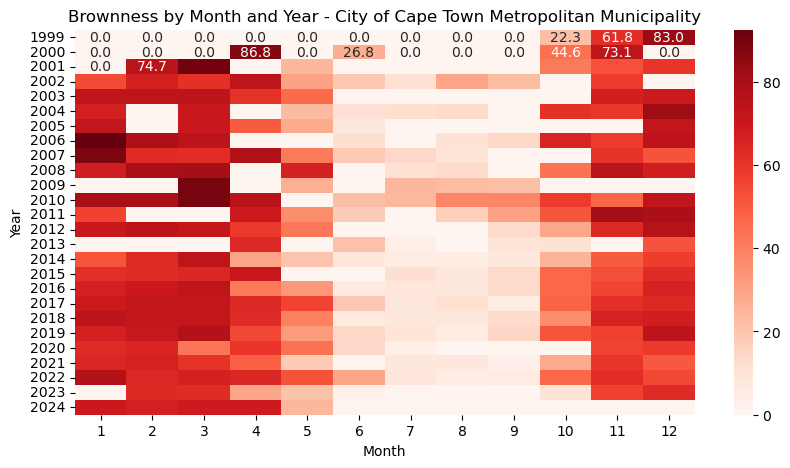

In [40]:
region = "City of Cape Town Metropolitan Municipality"
#calculate average color
average_brownness_csv(region)
#generate heatmap
brown_heatmap(region)

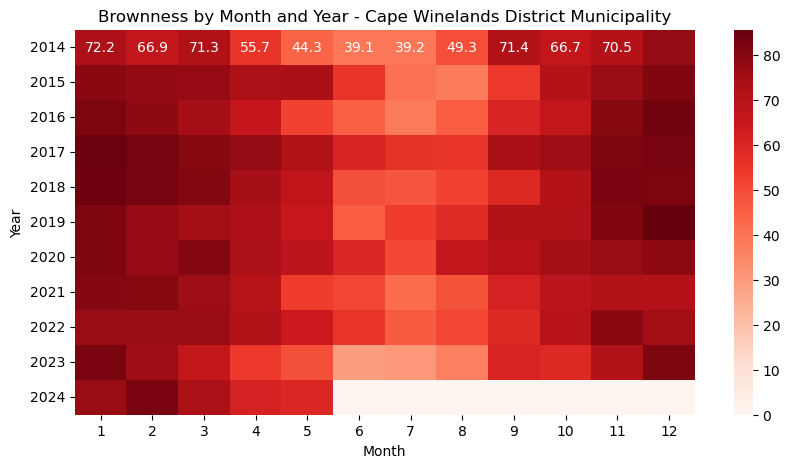

In [41]:
region = "Cape Winelands District Municipality"
#calculate average color
average_brownness_csv(region)
#generate heatmap
brown_heatmap(region)

### Repeat for circles

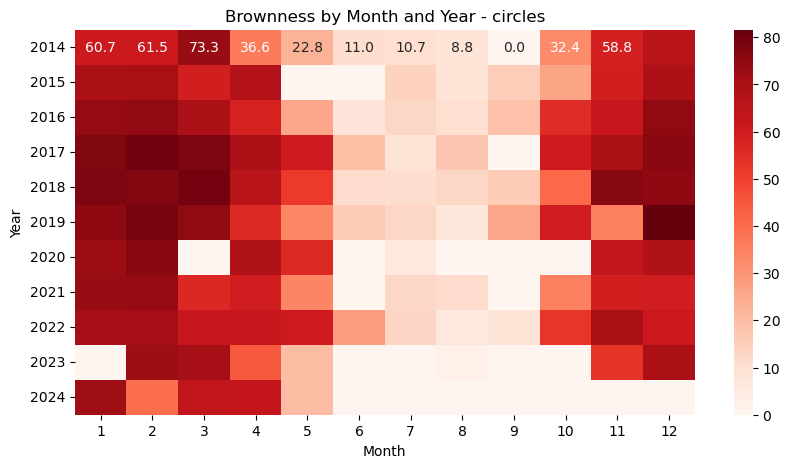

In [42]:
region = "circles"
#calculate average color
average_brownness_csv(region)
#generate heatmap
brown_heatmap(region)

In [43]:
#make bar chart of average brownness_csv
def brown_bar_chart(region_name):
    # Read the CSV file
    csv_file = f'output/0_output_csv/{region_name}_average_brownness.csv'
    df = pd.read_csv(csv_file)

    # Create a bar chart
    fig = px.bar(df, x='Year', y='Brownness_Percentage', title=f'Average Brownness by Month and Year - {region_name}',hover_data=["Month"])
    fig.show()

#make box and whisker plot of average brownness_csv
def brown_box_plot(region_name):
    # Read the CSV file
    csv_file = f'output/0_output_csv/{region_name}_average_brownness.csv'
    df = pd.read_csv(csv_file)

    # Create a box plot
    fig = px.box(df, x='Year', y='Brownness_Percentage', title=f'Average Brownness by Month and Year - {region_name}')
    fig.show()

#make violin plot of average brownness_csv
def brown_violin_plot(region_name):
    # Read the CSV file
    csv_file = f'output/0_output_csv/{region_name}_average_brownness.csv'
    df = pd.read_csv(csv_file)

    # Create a violin plot
    fig = px.violin(df, x='Year', y='Brownness_Percentage', title=f'Average Brownness by Month and Year - {region_name}')
    fig.show()

In [44]:
region = "City of Cape Town Metropolitan Municipality"
brown_bar_chart(region)

In [47]:
brown_box_plot(region)

In [46]:
brown_violin_plot(region)

In [214]:
region = "circles"
brown_bar_chart(region)

### Now for even smaller home region

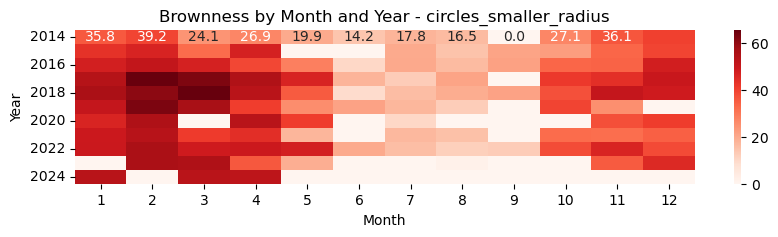

In [216]:
region = "circles_smaller_radius"
#calculate average color
average_brownness_csv(region)
#generate heatmap
brown_heatmap(region)

In [217]:
brown_bar_chart(region)

Try for Europe

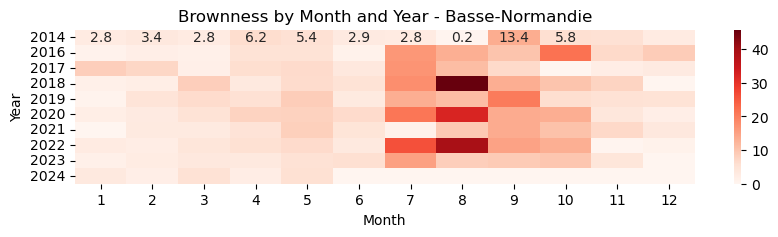

In [28]:
region = "Basse-Normandie"
#calculate average color
average_brownness_csv(region)
#generate heatmap
brown_heatmap(region)

In [29]:
region = "Basse-Normandie"
brown_bar_chart(region)

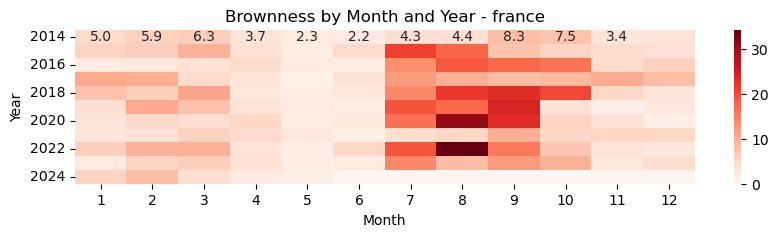

In [30]:
region = "france"
#calculate average color
average_brownness_csv(region)
#generate heatmap
brown_heatmap(region)

In [31]:
region = "france"
brown_bar_chart(region)

In [34]:
region

'france'